#  VQ-PINN for 2D Taylor–Green Vortex (Pennylane + PyTorch)

This notebook implements a Variational Quantum Physics-Informed Neural Network (VQ-PINN)
for the 2D incompressible Navier–Stokes (Taylor–Green vortex) benchmark.

It matches your classical PINN/Pseudo-spectral pipelines:
- same domain `[0, 2π] × [0, 2π]`,
- same metrics (L2, Linf, correlation) against your reference `.npz`,
- standardized N=32 grid for evaluation.

**Notes**
- Uses PennyLane (not Qiskit) for all quantum ops.
- Quantum layer is wrapped as a Torch module so we can train end-to-end with Adam.
- Tracks shots, qubits, and approximate circuit-call counts for reporting.


In [1]:
!pip install pennylane torch numpy matplotlib tqdm scipy --quiet

import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import RegularGridInterpolator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 57.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 77.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
L = 2*np.pi
NX = NY = 32
T_FINAL = 0.1   # <-- IMPORTANT: time horizon for data + features + eval
REFERENCE_PATH="/kaggle/input/reference-date-safe/reference_data_safe.npz"

In [3]:
# --- Cell 2: Config ---
# Physics / evaluation settings
# Physics / evaluation settings
Re = 100.0
nu = 1.0 / Re

# Evaluation grid (kept consistent with baseline)
nx_eval = NX
ny_eval = NY
t_eval  = T_FINAL

# Quantum settings (match earlier experiment)
N_QUBITS = 6
N_LAYERS = 4
SHOTS    = 1024
SEED     = 42

rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Re={Re}, nu={nu}, qubits={N_QUBITS}, layers={N_LAYERS}, shots={SHOTS}")

Re=100.0, nu=0.01, qubits=6, layers=4, shots=1024


In [4]:
# --- Cell 3: Utilities (vorticity, interpolation, metrics) ---
def vorticity_from_uv(u, v):
    Nx, Ny = u.shape
    kx = np.fft.fftfreq(Nx, d=(2*np.pi)/Nx)*2*np.pi
    ky = np.fft.fftfreq(Ny, d=(2*np.pi)/Ny)*2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    u_hat, v_hat = np.fft.fft2(u), np.fft.fft2(v)
    w_hat = 1j*KX*v_hat - 1j*KY*u_hat
    return np.real(np.fft.ifft2(w_hat))

def interp_field_to_grid(field_ref, x_ref, y_ref, x_tgt, y_tgt):
    X_t, Y_t = np.meshgrid(x_tgt, y_tgt, indexing='ij')
    interp = RegularGridInterpolator((x_ref, y_ref), field_ref,
                                     bounds_error=False, fill_value=None)
    XY = np.c_[X_t.ravel(), Y_t.ravel()]
    return interp(XY).reshape(X_t.shape)

def compute_metrics_vorticity(w_pred, x_pred, y_pred, ref_npz_path=REFERENCE_PATH, plot_diff=True):
    ref = np.load(ref_npz_path, allow_pickle=True)
    u_ref, v_ref = ref['u'], ref['v']

    Nx_ref, Ny_ref = u_ref.shape
    x_ref = np.linspace(0, 2*np.pi, Nx_ref, endpoint=False)
    y_ref = np.linspace(0, 2*np.pi, Ny_ref, endpoint=False)
    w_ref = vorticity_from_uv(u_ref, v_ref)

    # Wrap into periodic box if needed
    x_pred = np.mod(x_pred, 2*np.pi)
    y_pred = np.mod(y_pred, 2*np.pi)

    # Interpolate ref to pred grid
    w_ref_interp = interp_field_to_grid(w_ref, x_ref, y_ref, x_pred, y_pred)

    # Metrics with auto sign check
    def metrics(w):
        L2 = np.linalg.norm(w - w_ref_interp) / np.linalg.norm(w_ref_interp)
        Linf = np.max(np.abs(w - w_ref_interp))
        corr = np.corrcoef(w.ravel(), w_ref_interp.ravel())[0,1]
        return L2, Linf, corr
    L2a, Linfa, ca = metrics(w_pred)
    L2b, Linfb, cb = metrics(-w_pred)

    if abs(cb) > abs(ca):
        flipped = True; L2, Linf, corr = L2b, Linfb, cb; w_use = -w_pred
    else:
        flipped = False; L2, Linf, corr = L2a, Linfa, ca; w_use = w_pred

    print(f"📊 L2 Error:    {L2:.4e}")
    print(f"📊 L∞ Error:    {Linf:.4e}")
    print(f"📊 Correlation: {corr:.4f}  (sign-flip used: {flipped})")

    if plot_diff:
        plt.figure(figsize=(5,4))
        plt.imshow((w_use - w_ref_interp).T, origin='lower', cmap='bwr',
                   extent=(0,2*np.pi,0,2*np.pi))
        plt.colorbar(label="ΔVorticity")
        plt.title("VQ-PINN: Vorticity Difference vs Reference")
        plt.xlabel("x"); plt.ylabel("y")
        plt.show()

    return {"L2":L2, "Linf":Linf, "corr":corr, "flipped":flipped}


In [5]:
# --- Cell 4: Quantum feature map + ansatz as a Torch layer ---
# We'll use angle encoding for (x,y,t) with Fourier features to expand to N_QUBITS inputs.
def fourier_features(xyt, n_freq=2):
    # xyt: (batch, 3) with x,y in [0, 2π], t in [0, T_FINAL]
    x, y, t = xyt[:,0:1], xyt[:,1:2], xyt[:,2:3]
    tt = 2*np.pi * (t / T_FINAL)  # <-- fixed scaling to [0, 2π], not batch-dependent
    feats = [x, y, tt]
    for k in range(2, n_freq+2):
        feats += [torch.sin(k*x), torch.cos(k*x),
                  torch.sin(k*y), torch.cos(k*y),
                  torch.sin(k*tt), torch.cos(k*tt)]
    return torch.cat(feats, dim=1)


# Make sure we have at least N_QUBITS features; if more, truncate; if fewer, pad
def pad_to_qubits(feats, n_qubits):
    B, F = feats.shape
    if F >= n_qubits:
        return feats[:, :n_qubits]
    pad = torch.zeros(B, n_qubits - F, device=feats.device, dtype=feats.dtype)
    return torch.cat([feats, pad], dim=1)

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="parameter-shift", shots=None)
def qnode(inputs, weights):
    # inputs: shape (N_QUBITS,)
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    # Measure two observables to produce 2 outputs (u, v)
    return [qml.expval(qml.PauliZ(0)), qml.expval(qml.PauliZ(1))]

# --- PATCH: redefine QuantumLayer to fix Float/Double mismatch ---

class QuantumLayer(torch.nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS):
        super().__init__()
        self.n_qubits = n_qubits
        # weights in float32
        w_shape = (n_layers, n_qubits, 3)
        self.weights = torch.nn.Parameter(0.01 * torch.randn(*w_shape, dtype=torch.float32))
        self.head = torch.nn.Linear(2, 2)  # float32 by default
        self.register_buffer("circuit_calls", torch.zeros(1, dtype=torch.long))

    def forward(self, xyt):
        # Feature map -> ensure float32 before sending into qnode
        feats = fourier_features(xyt).to(torch.float32)
        feats = pad_to_qubits(feats, self.n_qubits)

        outs = []
        # IMPORTANT: qnode returns float64 by default; we will cast to float32.
        for i in range(feats.shape[0]):
            out_i = qnode(feats[i], self.weights)           # returns two expectations (likely float64)
            outs.append(torch.stack(out_i))

        out = torch.stack(outs, dim=0)                      # (B, 2), dtype float64
        self.circuit_calls += feats.shape[0]
        out = out.to(torch.float32)                         # <-- cast to float32 to match Linear head
        out = self.head(out)
        return out


In [6]:
# --- Cell 5: VQ-PINN model (wrap quantum layer) ---
class VQ_PINN_NS(nn.Module):
    def __init__(self):
        super().__init__()
        self.quantum = QuantumLayer(n_qubits=N_QUBITS, n_layers=N_LAYERS)
    def forward(self, x, y, t):
        xyt = torch.cat([x, y, t], dim=1)
        return self.quantum(xyt)


In [7]:
# --- Cell 6: Physics residuals (reuse from classical PINN) ---
def navier_stokes_residual(model, x, y, t, nu):
    x.requires_grad_(True); y.requires_grad_(True); t.requires_grad_(True)
    out = model(x, y, t)
    u, v = out[:, [0]], out[:, [1]]

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]

    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v), create_graph=True)[0]

    f_u = u_t + (u*u_x + v*u_y) - nu*(u_xx + u_yy)
    f_v = v_t + (u*v_x + v*v_y) - nu*(v_xx + v_yy)
    continuity = u_x + v_y
    return f_u, f_v, continuity


In [8]:
# --- Cell 7: Data generation (same distribution as PINN) ---
def generate_training_data(N_col=1024, N_ic=512, T_final=T_FINAL):
    x_col = 2*np.pi*np.random.rand(N_col, 1)
    y_col = 2*np.pi*np.random.rand(N_col, 1)
    t_col = T_final*np.random.rand(N_col, 1)  # t ∈ [0, 0.1]

    x_ic = 2*np.pi*np.random.rand(N_ic, 1)
    y_ic = 2*np.pi*np.random.rand(N_ic, 1)
    t_ic = np.zeros_like(x_ic)
    u_ic = np.sin(x_ic)*np.cos(y_ic)
    v_ic = -np.cos(x_ic)*np.sin(y_ic)

    return {"col": (x_col, y_col, t_col), "ic": (x_ic, y_ic, t_ic, u_ic, v_ic)}


In [9]:
# --- Cell 8: Weighted loss & training loop ---
def vq_pinn_loss(model, data, nu):
    x_col, y_col, t_col = [torch.tensor(a, dtype=torch.float32, device=device) for a in data["col"]]
    x_ic, y_ic, t_ic, u_ic, v_ic = [torch.tensor(a, dtype=torch.float32, device=device) for a in data["ic"]]

    f_u, f_v, f_c = navier_stokes_residual(model, x_col, y_col, t_col, nu)
    loss_pde  = (f_u.pow(2).mean() + f_v.pow(2).mean())
    loss_cont = f_c.pow(2).mean()

    uv_ic = model(x_ic, y_ic, t_ic)
    u_ic_pred, v_ic_pred = uv_ic[:, [0]], uv_ic[:, [1]]
    loss_ic = ((u_ic_pred - u_ic)**2).mean() + ((v_ic_pred - v_ic)**2).mean()

    loss = 1.0*loss_ic + 0.5*loss_pde + 0.5*loss_cont
    return loss, loss_ic.item(), loss_pde.item(), loss_cont.item()

def train_vq_pinn(model, data, nu=0.01, lr=1e-3, epochs=2000, save_path="vq_pinn_ns.pt"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=500, gamma=0.7)

    losses, ic_l, pde_l, cont_l = [], [], [], []
    circuit_calls_hist = []

    for ep in tqdm(range(epochs)):
        opt.zero_grad()
        loss, a, b, c = vq_pinn_loss(model, data, nu)
        loss.backward()
        opt.step(); scheduler.step()

        losses.append(loss.item()); ic_l.append(a); pde_l.append(b); cont_l.append(c)
        circuit_calls_hist.append(int(model.quantum.circuit_calls.item()))

        if ep % 200 == 0:
            print(f"Epoch {ep:4d} | Loss={loss.item():.3e} | IC={a:.2e} | PDE={b:.2e} | Cont={c:.2e} | Circuit calls={circuit_calls_hist[-1]}")

    torch.save(model.state_dict(), save_path)
    print(f"✅ Saved VQ-PINN to {save_path}")
    return losses, ic_l, pde_l, cont_l, circuit_calls_hist


 20%|██        | 1/5 [12:10<48:43, 730.83s/it]

Epoch    0 | Loss=1.006e+01 | IC=1.02e+00 | PDE=1.81e+01 | Cont=2.01e-02 | Circuit calls=70


100%|██████████| 5/5 [57:53<00:00, 694.65s/it]


✅ Saved VQ-PINN to vq_pinn_ns.pt
📊 L2 Error:    1.0116e+00
📊 L∞ Error:    2.3399e+00
📊 Correlation: 0.0149  (sign-flip used: False)


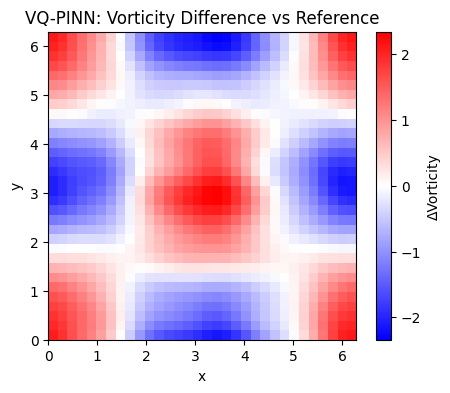

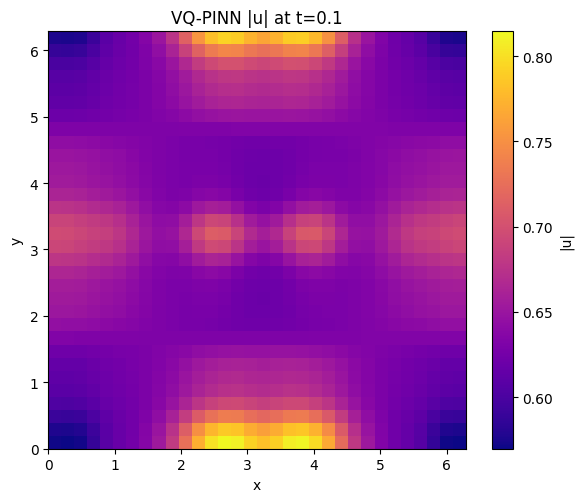

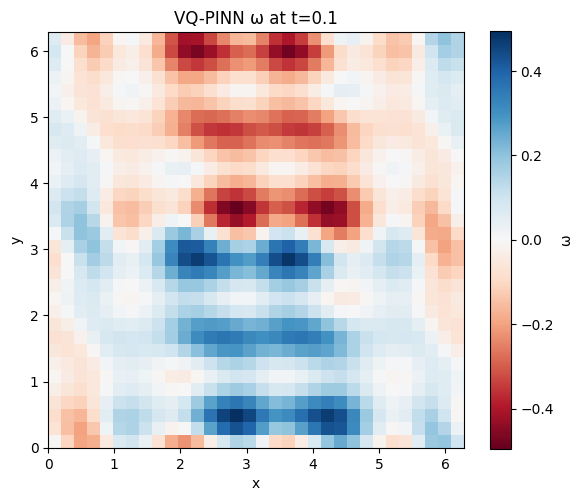

In [10]:
# --- Cell 9: Evaluation on N=32 grid and metrics ---
def evaluate_vq_pinn(model, nx=32, ny=32, t_eval=1.0):
    x = np.linspace(0, 2*np.pi, nx, endpoint=False)
    y = np.linspace(0, 2*np.pi, ny, endpoint=False)
    X, Y = np.meshgrid(x, y, indexing='ij')
    T = t_eval*np.ones_like(X)

    X_t = torch.tensor(X.reshape(-1,1), dtype=torch.float32, device=device)
    Y_t = torch.tensor(Y.reshape(-1,1), dtype=torch.float32, device=device)
    T_t = torch.tensor(T.reshape(-1,1), dtype=torch.float32, device=device)

    with torch.no_grad():
        uv = model(X_t, Y_t, T_t).cpu().numpy()
    U = uv[:,0].reshape(nx, ny)
    V = uv[:,1].reshape(nx, ny)
    return X, Y, U, V

data = generate_training_data(N_col=1024, N_ic=512, T_final=T_FINAL)
model = VQ_PINN_NS()
losses, ic_l, pde_l, cont_l, calls = train_vq_pinn(
    model, data, nu=nu, lr=1e-3, epochs=100, save_path="vq_pinn_ns.pt"
)


# Evaluate exactly at t=0.1 on 32×32
X, Y, U, V = evaluate_vq_pinn(model_test, nx=NX, ny=NY, t_eval=T_FINAL)
w = vorticity_from_uv(U, V)

# Metrics vs reference at t=0.1
metrics_vq = compute_metrics_vorticity(w, np.unique(X), np.unique(Y))
np.savez_compressed("metrics_VQ_PINN.npz", **metrics_vq)

# Plots at t=0.1
speed = np.sqrt(U**2 + V**2)
plt.figure(figsize=(6,5))
plt.imshow(speed.T, origin='lower', cmap='plasma',
           extent=(0, 2*np.pi, 0, 2*np.pi))
plt.colorbar(label="|u|"); plt.title("VQ-PINN |u| at t=0.1")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
plt.imshow(w.T, origin='lower', cmap='RdBu',
           extent=(0, 2*np.pi, 0, 2*np.pi))
plt.colorbar(label="ω"); plt.title("VQ-PINN ω at t=0.1")
plt.xlabel("x"); plt.ylabel("y"); plt.tight_layout(); plt.show()



np.savez_compressed("metrics_VQ_PINN.npz", **metrics_vq)
